# House Prices: Advanced Regression Techniques
## Fase 1: Exploração e Limpeza de Dados

**Objetivo:** Conhecer o dataset, identificar problemas e preparar os dados para modelagem.

**Métrica:** RMSLE (Root Mean Squared Log Error)

In [ ]:
# Imports básicos
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Bibliotecas carregadas!')

Bibliotecas carregadas!


In [ ]:
# Carregar datasets
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f'Train: {train.shape[0]} linhas, {train.shape[1]} colunas')
print(f'Test: {test.shape[0]} linhas, {test.shape[1]} colunas')

Train: 1460 linhas, 81 colunas
Test: 1459 linhas, 80 colunas


## 1. Visão Geral dos Dados

In [ ]:
# Primeiras linhas
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
# Info
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [ ]:
# Estatística descritiva
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [ ]:
# Tipos de dados
print('Colunas numéricas:', train.select_dtypes(include=[np.number]).shape[1])
print('Colunas categóricas:', train.select_dtypes(include=['object']).shape[1])

# Listar colunas categóricas
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
print(f'\nColunas categóricas ({len(cat_cols)}):')
print(cat_cols)

Colunas numéricas: 38
Colunas categóricas: 43

Colunas categóricas (43):
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


C:\Users\marlo\AppData\Local\Temp\ipykernel_37612\3068930886.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print('Colunas categóricas:', train.select_dtypes(include=['object']).shape[1])
C:\Users\marlo\AppData\Local\Temp\ipykernel_37612\3068930886.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.py

## 2. Análise do Target (SalePrice)

Média: $180,921
Mediana: $163,000
Desvio Padrão: $79,443
Assimetria (Skew): 1.883
Curtose (Kurtosis): 6.536


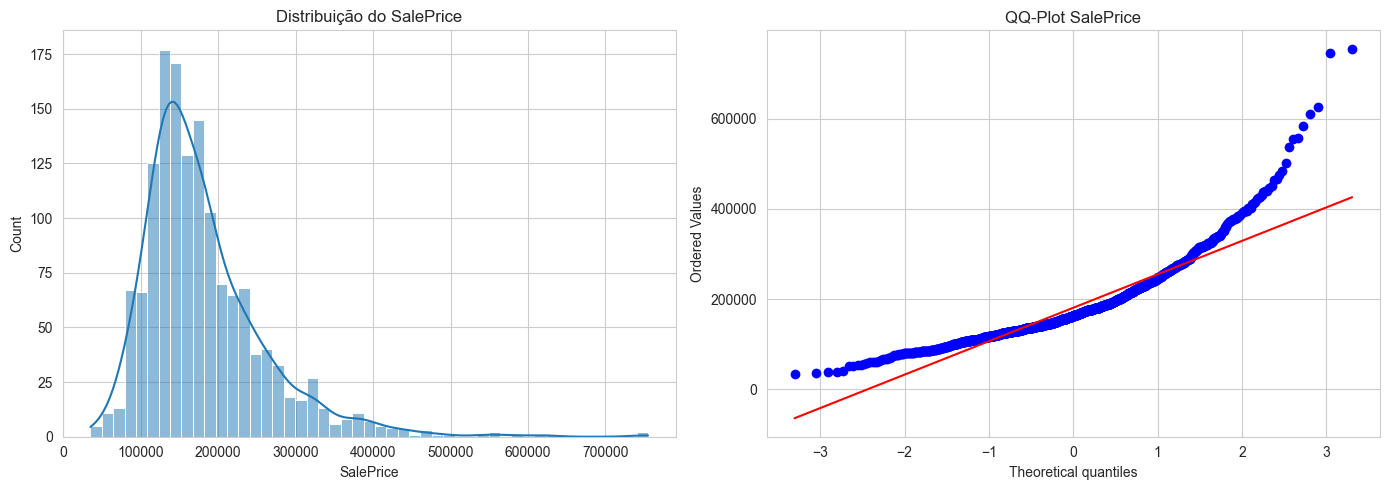

In [ ]:
# Distribuição do SalePrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
sns.histplot(train['SalePrice'], kde=True, ax=axes[0])
axes[0].set_title('Distribuição do SalePrice')
axes[0].set_xlabel('SalePrice')

# QQ-Plot
stats.probplot(train['SalePrice'], plot=axes[1])
axes[1].set_title('QQ-Plot SalePrice')

plt.tight_layout()
plt.savefig('../reports/sale_price_distribution.png', dpi=250, bbox_inches='tight')

# Estatísticas
print(f'Média: ${train["SalePrice"].mean():,.0f}')
print(f'Mediana: ${train["SalePrice"].median():,.0f}')
print(f'Desvio Padrão: ${train["SalePrice"].std():,.0f}')
print(f'Assimetria (Skew): {train["SalePrice"].skew():.3f}')
print(f'Curtose (Kurtosis): {train["SalePrice"].kurtosis():.3f}')

## 3. Valores Faltantes

Colunas com valores faltantes: 19
              Faltantes     %
PoolQC             1453  99.5
MiscFeature        1406  96.3
Alley              1369  93.8
Fence              1179  80.8
MasVnrType          872  59.7
FireplaceQu         690  47.3
LotFrontage         259  17.7
GarageType           81   5.5
GarageYrBlt          81   5.5
GarageFinish         81   5.5
GarageQual           81   5.5
GarageCond           81   5.5
BsmtExposure         38   2.6
BsmtFinType2         38   2.6
BsmtQual             37   2.5
BsmtCond             37   2.5
BsmtFinType1         37   2.5
MasVnrArea            8   0.5
Electrical            1   0.1


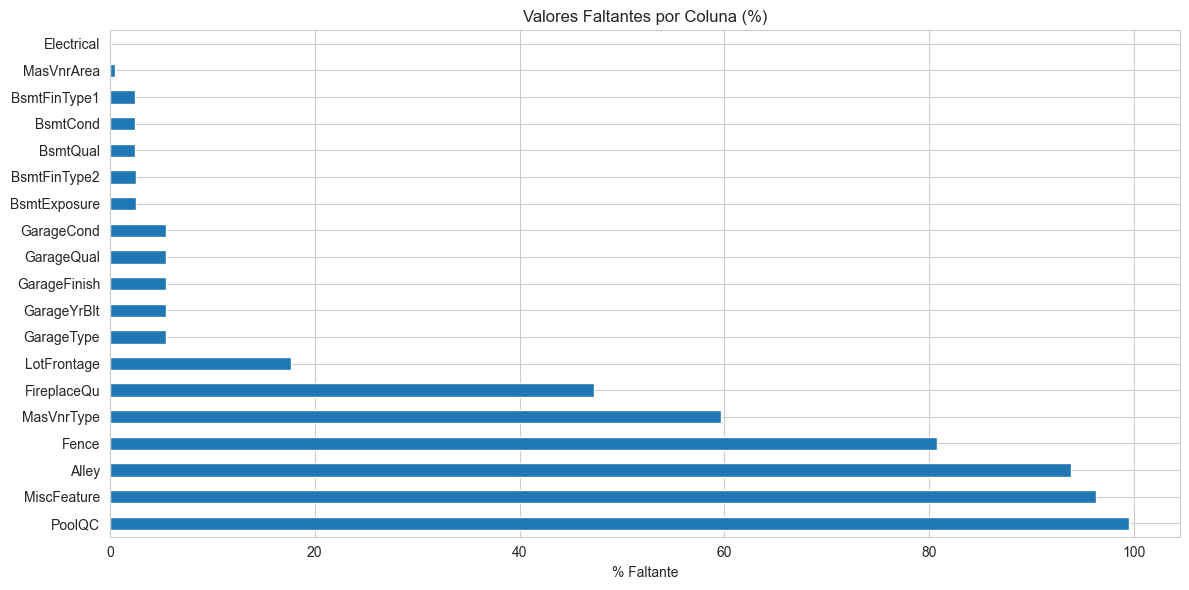

In [ ]:
# Valores faltantes
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

print(f'Colunas com valores faltantes: {len(missing)}')

missing_df = pd.DataFrame({
    'Faltantes': missing,
    '%': missing_pct
})
print(missing_df.to_string())

# Visualizar
fig, ax = plt.subplots(figsize=(12, max(6, len(missing) * 0.3)))
missing_pct.plot(kind='barh', ax=ax)
ax.set_title('Valores Faltantes por Coluna (%)')
ax.set_xlabel('% Faltante')
plt.tight_layout()
plt.savefig('../reports/missing_values.png', dpi=150, bbox_inches='tight')


## 4. Correlações com SalePrice

In [ ]:
# Correlações numéricas com SalePrice
numeric_cols = train.select_dtypes(include=[np.number]).columns
correlations = train[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)

print('Top 15 correlações positivas:')
print(correlations.head(15).to_string())

print('\nTop 5 correlações negativas:')
print(correlations.tail(5).to_string())

Top 15 correlações positivas:
SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420

Top 5 correlações negativas:
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907


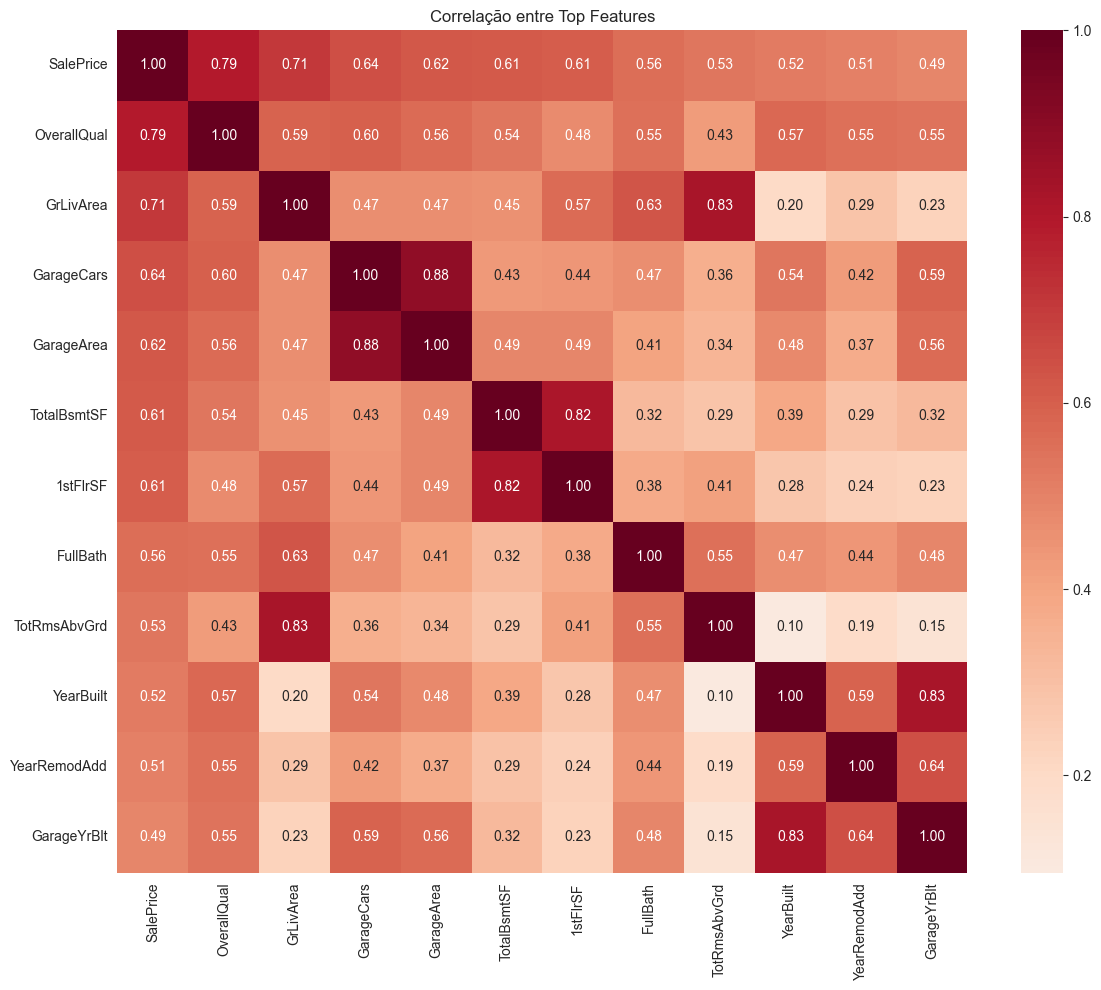

In [ ]:
# Heatmap das top correlações
top_features = correlations.head(12).index.tolist()
corr_matrix = train[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Correlação entre Top Features')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')


## 5. Análise de Outliers

Outliers potenciais (GrLivArea > 4000 e SalePrice < 300k): 2
        Id  GrLivArea  SalePrice
523    524       4676     184750
1298  1299       5642     160000


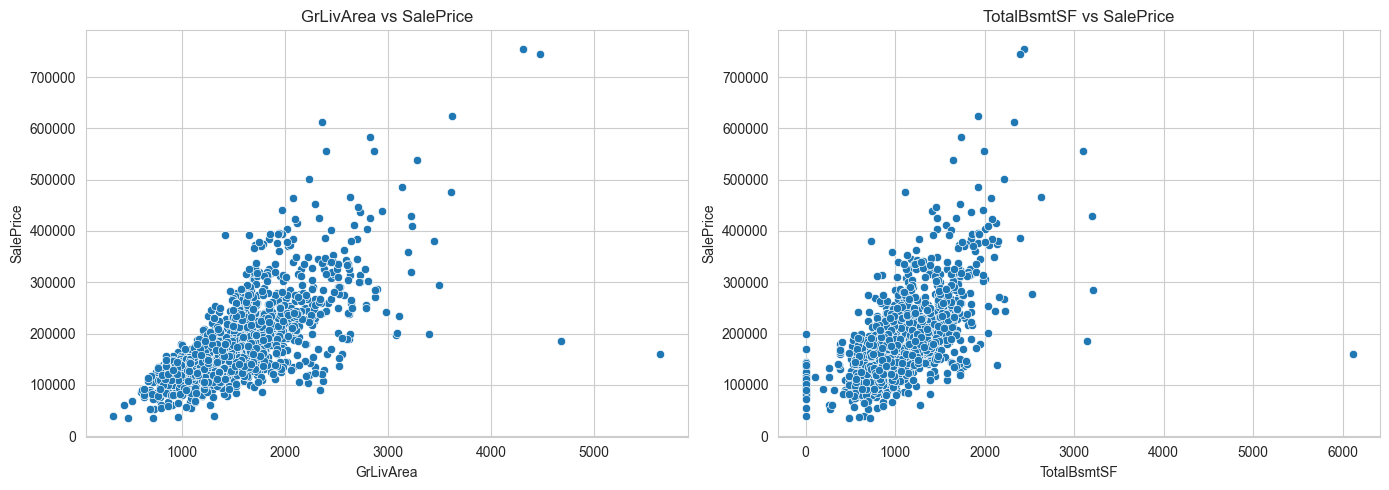

In [ ]:
# Scatter plot: GrLivArea vs SalePrice (relação conhecida)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=train, x='GrLivArea', y='SalePrice', ax=axes[0])
axes[0].set_title('GrLivArea vs SalePrice')

sns.scatterplot(data=train, x='TotalBsmtSF', y='SalePrice', ax=axes[1])
axes[1].set_title('TotalBsmtSF vs SalePrice')

plt.tight_layout()
plt.savefig('../reports/outliers.png', dpi=150, bbox_inches='tight')

# Identificar outliers óbvios
outliers = train[(train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000)]
print(f'Outliers potenciais (GrLivArea > 4000 e SalePrice < 300k): {len(outliers)}')
if len(outliers) > 0:
    print(outliers[['Id', 'GrLivArea', 'SalePrice']].to_string())

## 6. Features Categóricas Importantes

C:\Users\marlo\AppData\Local\Temp\ipykernel_37612\747349561.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


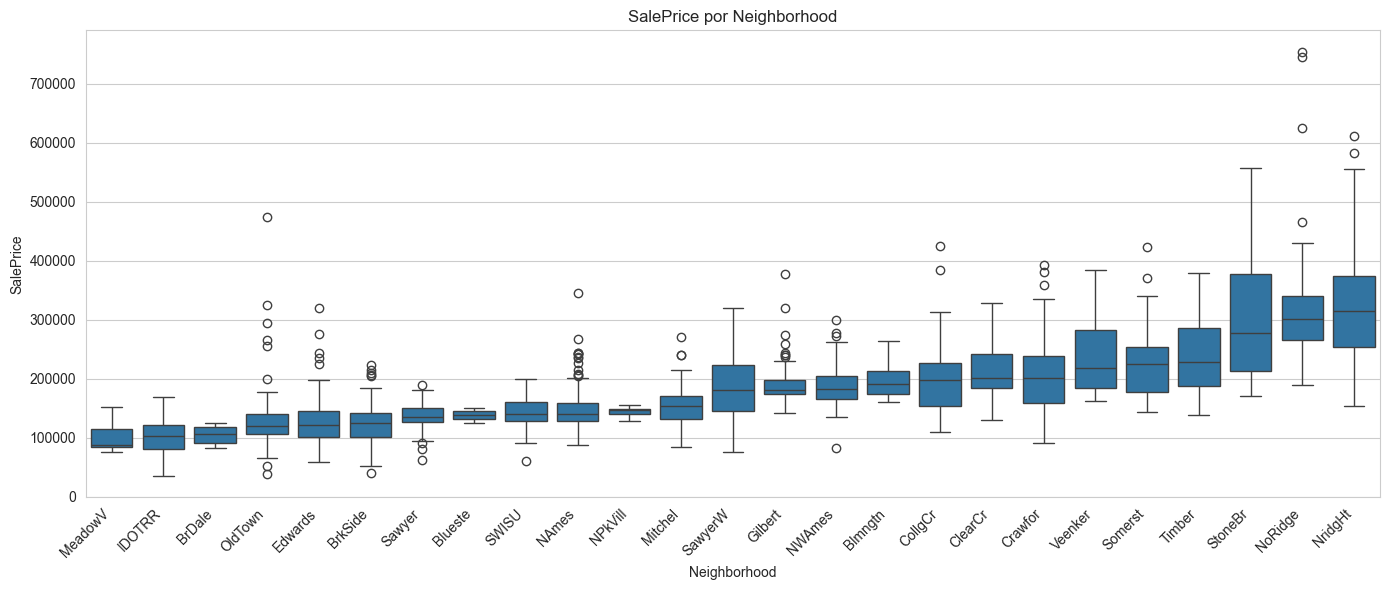

In [ ]:
# Analisar Neighborhood vs SalePrice
fig, ax = plt.subplots(figsize=(14, 6))
order = train.groupby('Neighborhood')['SalePrice'].median().sort_values().index
sns.boxplot(data=train, x='Neighborhood', y='SalePrice', order=order, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.set_title('SalePrice por Neighborhood')
plt.tight_layout()
plt.savefig('../reports/neighborhood_price.png', dpi=150, bbox_inches='tight')


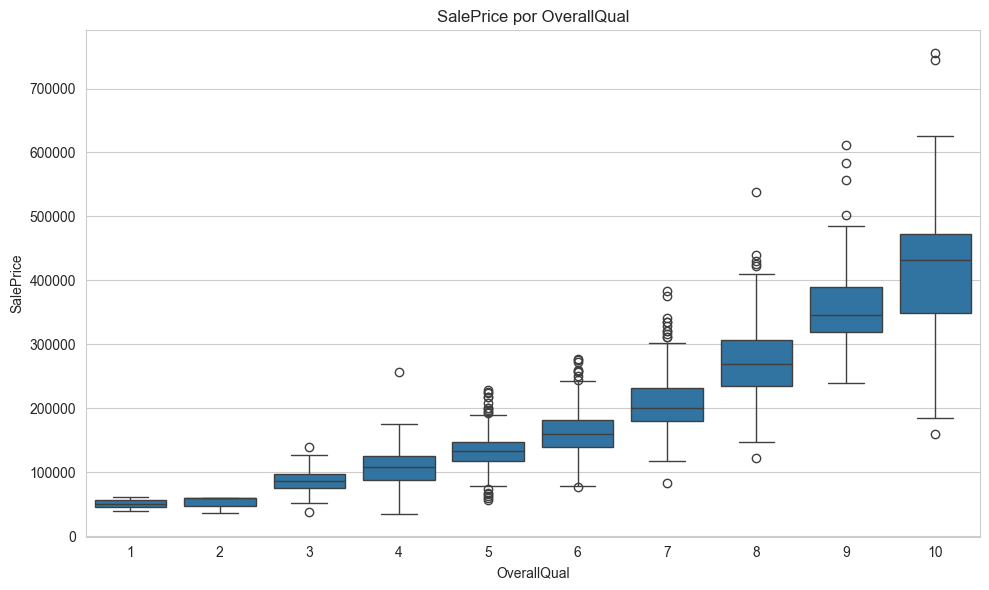

In [ ]:
# OverallQual vs SalePrice
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=train, x='OverallQual', y='SalePrice', ax=ax)
ax.set_title('SalePrice por OverallQual')
plt.tight_layout()
plt.savefig('../reports/overallqual_price.png', dpi=150, bbox_inches='tight')


## 7. Resumo e Próximos Passos

### O que encontramos:
- **SalePrice** é assimétrica (skew > 0) — pode precisar de log transform
- **Valores faltantes** em várias colunas — precisamos decidir estratégia
- **Correlações fortes**: OverallQual, GrLivArea, GarageCars, TotalBsmtSF
- **Outliers** identificados em GrLivArea
- **Neighborhood** tem impacto significativo no preço

### Próximos passos (Fase 2):
1. Tratar valores faltantes
2. Feature engineering
3. Encoding de variáveis categóricas
4. Normalização do target
5. Modelo baseline